In [ ]:
import numpy as np
import pandas as pd
from hiprof.base.graph import Graph
from hiprof.verification.falsifier import HPFalsifier

Consider the following ADMG (see https://github.com/pedemonte96/causaleffect?tab=readme-ov-file):

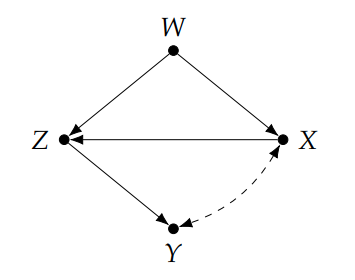

Using the ID algorithm, one can find: $$p(y|do(x))=\sum_{w,z} p(w)p(z|w,x)\left(\sum_{x'} p(x'|w)p(y|w,x',z)\right).$$

In [ ]:
nodes = ["X", "Z", "Y", "W"]
directed = pd.DataFrame(
    [[0, 1, 0, 0],
     [0, 0, 1, 0],
     [0, 0, 0, 0],
     [1, 1, 0, 0]],
    index=nodes,
    columns=nodes,
)
bidirected = pd.DataFrame(
    np.zeros((len(nodes), len(nodes))),
    index=nodes,
    columns=nodes,
)
bidirected.loc["X", "Y"] = 1
bidirected.loc["Y", "X"] = 1
graph = Graph(directed=directed, bidirected=bidirected)

In [ ]:
formula = "INT_{W, Z} { p(W) p(Z | W, X=.) INT_{X'} { p(X' | W) p(Y | W, X', Z) } }"
falsifier = HPFalsifier(treatments='X', outcomes='Y', graph=graph)
falsifier.check(formula)

In [ ]:
formula = "p(Y | X=.)"
falsifier.check(formula)